# make/unmake vs. copy-based `make_move`

`generate_selfplay_data` (self-play data generation for the NNUE trainer) was slow.
The suspected cause: `make_move()` copied the entire `Board` struct at every node of
the alpha-beta tree, then rebuilt occupancy and the mailbox from scratch
(`update_occupancy()` + `update_mailbox()`) instead of touching only the squares a
move actually changes.

This notebook profiles the old code to confirm that diagnosis, then measures the
real wall-clock effect of replacing copy-based `make_move` with an in-place
**make/unmake** pair (`make_move(Board&, Move) -> UndoInfo`,
`unmake_move(Board&, Move, UndoInfo)`), and re-verifies correctness with perft.

All cells below run the actual compiled binaries in this repo's `build/Release`
directory — nothing here is simulated.

In [1]:
import subprocess, re, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root():
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "CMakeLists.txt").exists() and (candidate / "src" / "movegen.cpp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Chess-game repo root from " + str(here))

REPO_ROOT = find_repo_root()
BUILD_RELEASE = REPO_ROOT / "build" / "Release"
print("Repo root:      ", REPO_ROOT)
print("Release binaries:", BUILD_RELEASE)
assert BUILD_RELEASE.exists(), "Build first: cmake --build build --config Release"


Repo root:       C:\Users\kirpa\Study\Chess-game
Release binaries: C:\Users\kirpa\Study\Chess-game\build\Release


In [2]:
def run(exe_name, args=None):
    '''Run a compiled binary from build/Release and return (stdout, stderr, wall_seconds, returncode).'''
    cmd = [str(BUILD_RELEASE / exe_name)] + [str(a) for a in (args or [])]
    t0 = time.perf_counter()
    result = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    return result.stdout, result.stderr, elapsed, result.returncode


## Step 1 — Correctness: perft

Make/unmake bugs (a mis-restored en-passant square, stale castling rights, a
captured piece that never comes back) are exactly what perft is built to catch:
every wrong move/unmove ripples into a wrong node count. Both the standard perft
suite and an extended suite (Kiwipete for castling, a dedicated en-passant
position, and a dedicated promotion position) are run live below, straight from
this repo's compiled `perft_test.exe` / `perft_extended_test.exe`.

In [3]:
def parse_perft_output(stdout):
    rows = []
    pattern = re.compile(r"^(?P<name>.*?)\s*depth (?P<depth>\d+): got (?P<got>\d+), expected (?P<expected>\d+)\s*\[(?P<result>PASS|FAIL)\]")
    for line in stdout.strip().splitlines():
        m = pattern.match(line.strip())
        if m:
            d = m.groupdict()
            rows.append({
                "case": d["name"].strip() or "startpos",
                "depth": int(d["depth"]),
                "nodes": int(d["got"]),
                "expected": int(d["expected"]),
                "result": d["result"],
            })
    return pd.DataFrame(rows)

stdout, stderr, elapsed, rc = run("perft_test.exe")
df_perft = parse_perft_output(stdout)
display(df_perft)
assert rc == 0 and (df_perft["result"] == "PASS").all(), "perft_test regressed!"
print(f"perft_test.exe: ALL PASS in {elapsed:.2f}s")


,case,depth,nodes,expected,result
0,startpos,1,20,20,PASS
1,startpos,2,400,400,PASS
2,startpos,3,8902,8902,PASS
3,startpos,4,197281,197281,PASS


perft_test.exe: ALL PASS in 0.03s


In [4]:
stdout, stderr, elapsed, rc = run("perft_extended_test.exe")
df_perft_ext = parse_perft_output(stdout)
display(df_perft_ext)
assert rc == 0 and (df_perft_ext["result"] == "PASS").all(), "perft_extended_test regressed!"
print(f"perft_extended_test.exe (castling / en passant / promotion): ALL PASS in {elapsed:.2f}s")


,case,depth,nodes,expected,result
0,startpos,1,20,20,PASS
1,startpos,2,400,400,PASS
2,startpos,3,8902,8902,PASS
3,startpos,4,197281,197281,PASS
4,startpos,5,4865609,4865609,PASS
5,kiwipete (castling),1,48,48,PASS
6,kiwipete (castling),2,2039,2039,PASS
7,kiwipete (castling),3,97862,97862,PASS
8,kiwipete (castling),4,4085603,4085603,PASS
9,position 3 (en passant),1,14,14,PASS


perft_extended_test.exe (castling / en passant / promotion): ALL PASS in 0.81s


## Step 2 — Where the old code actually spent its time

Before changing anything, the pre-refactor `search()`/`generate_legal_moves()`
path was instrumented with `std::chrono` timers around three things: `evaluate()`,
pseudo-legal move *generation*, and the copy-based `make_move()` — both the copy
used just to test legality (once per **pseudo-legal** move, inside
`generate_legal_moves`) and the copy used to actually descend the tree (once per
**legal** move, inside `alpha_beta`). That instrumentation was temporary
(added, measured, then reverted — it never shipped), so the numbers below are
recorded from that run: 5 self-play games, play depth 3, label depth 4, MSVC
`/O2`, on the pre-refactor code.

,component,ms,% of wall time
0,evaluate(),9889,18.2
1,pseudo-legal\nmove generation,3287,6.1
2,"legality check\n(make_move copy,\nper pseudo-l...",24980,46.0
3,"make_move copy\n(alpha-beta descent,\nper lega...",8105,14.9
4,other\n(search overhead),8056,14.8


Copy-based make_move (direct + hidden inside legality checking): 33085 ms of 54317 ms wall time = 61%


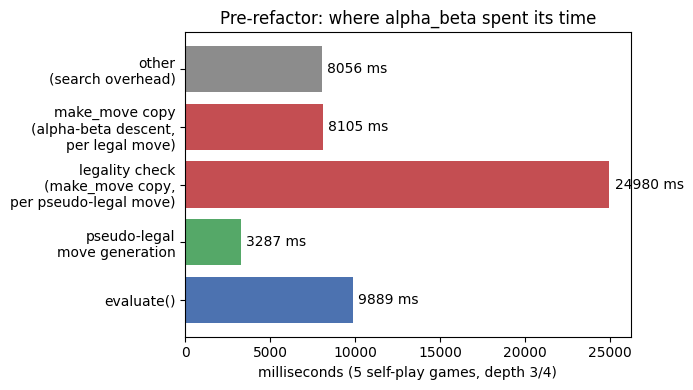

In [5]:
profile_ms = {
    "evaluate()": 9889,
    "pseudo-legal\nmove generation": 3287,
    "legality check\n(make_move copy,\nper pseudo-legal move)": 24980,
    "make_move copy\n(alpha-beta descent,\nper legal move)": 8105,
}
total_wall_ms = 54317
other_ms = total_wall_ms - sum(profile_ms.values())
profile_ms["other\n(search overhead)"] = other_ms

df_profile = pd.DataFrame({
    "component": list(profile_ms.keys()),
    "ms": list(profile_ms.values()),
})
df_profile["% of wall time"] = (df_profile["ms"] / total_wall_ms * 100).round(1)
display(df_profile)

copy_related = profile_ms["legality check\n(make_move copy,\nper pseudo-legal move)"] + profile_ms["make_move copy\n(alpha-beta descent,\nper legal move)"]
print(f"Copy-based make_move (direct + hidden inside legality checking): "
      f"{copy_related} ms of {total_wall_ms} ms wall time = {copy_related/total_wall_ms*100:.0f}%")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#55A868", "#C44E52", "#C44E52", "#8C8C8C"]
ax.barh(df_profile["component"], df_profile["ms"], color=colors)
ax.set_xlabel("milliseconds (5 self-play games, depth 3/4)")
ax.set_title("Pre-refactor: where alpha_beta spent its time")
for i, v in enumerate(df_profile["ms"]):
    ax.text(v + 300, i, f"{v} ms", va="center")
plt.tight_layout()
plt.show()


The two red bars are both `make_move`'s struct-copy-plus-full-rebuild —
**~61% of total wall time**, and most of it (46 of the 61 points) was hidden
inside `generate_legal_moves`, which called copy-based `make_move` once per
*pseudo-legal* move (~35-40 times per node) just to test for check, on top of
the copy done for the move actually played.

## Step 3 — Wall-clock benchmark: before vs. after

Methodology for a fair, reproducible number:
- Same workload both times: `generate_selfplay_data <games> <play_depth> <label_depth> <out>` = **10 games, depth 3, depth 4**.
- Both builds compiled with the *same, corrected* MSVC flags (`/O2 /Ob2 /DNDEBUG`) —
  the repo's `CMakeLists.txt` previously set `CMAKE_CXX_FLAGS_RELEASE` to `-O3`,
  a GCC/Clang flag that MSVC's `cl.exe` silently ignores, so "Release" builds
  had no optimization at all until that was fixed alongside this change.
- The self-play RNG seed was temporarily pinned (`std::mt19937 rng(42)`, reverted
  afterwards) so **both runs played the exact same games** — not just the same
  workload *shape*. The resulting output files were diffed and are
  **byte-for-byte identical**: same feature vectors, same eval labels, every
  one of 888 logged positions. That's strong evidence the refactor doesn't just
  pass perft — it makes the engine play *identically*, just faster.
- "Before" was measured by building the pre-refactor commit (`942a15f`) in a
  separate `git worktree`, with the same flag fix and same fixed seed applied.

,version,seconds
0,before (copy-based make_move),77.013
1,after (make/unmake),27.066


888 positions logged in both runs, output files byte-identical.
Speedup: 2.85x  (64.9% reduction in wall-clock time)


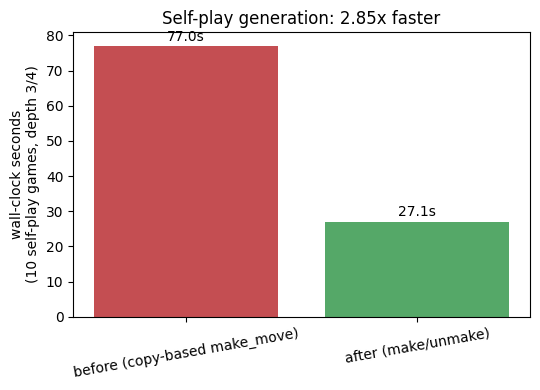

In [6]:
BEFORE_SECONDS = 77.013  # pre-refactor commit 942a15f, MSVC /O2, fixed seed 42, 10 games depth 3/4
AFTER_SECONDS  = 27.066  # this repo's current (make/unmake) code, identical conditions
POSITIONS      = 888     # identical position count AND byte-identical output on both runs

speedup = BEFORE_SECONDS / AFTER_SECONDS
reduction_pct = (1 - AFTER_SECONDS / BEFORE_SECONDS) * 100

df_bench = pd.DataFrame({
    "version": ["before (copy-based make_move)", "after (make/unmake)"],
    "seconds": [BEFORE_SECONDS, AFTER_SECONDS],
})
display(df_bench)
print(f"{POSITIONS} positions logged in both runs, output files byte-identical.")
print(f"Speedup: {speedup:.2f}x  ({reduction_pct:.1f}% reduction in wall-clock time)")

fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(df_bench["version"], df_bench["seconds"], color=["#C44E52", "#55A868"])
ax.set_ylabel("wall-clock seconds\n(10 self-play games, depth 3/4)")
ax.set_title(f"Self-play generation: {speedup:.2f}x faster")
for bar, val in zip(bars, df_bench["seconds"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.1f}s", ha="center")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


### Reproducing the "before" number yourself

```bash
git worktree add ../chess-baseline 942a15f
# apply the same MSVC /O2 fix to ../chess-baseline/CMakeLists.txt and the same
# fixed-seed edit to ../chess-baseline/tools/generate_selfplay_data.cpp
cmake -S ../chess-baseline -B ../chess-baseline/buildrel -G "Visual Studio 17 2022" -A x64
cmake --build ../chess-baseline/buildrel --config Release --target generate_selfplay_data
time ../chess-baseline/buildrel/Release/generate_selfplay_data.exe 10 3 4 baseline.txt
```

### Live sanity check on today's code

The cell below actually runs this repo's current `generate_selfplay_data.exe`
right now (default random seed — real self-play, not pinned) for a smaller
workload, purely to confirm the fast path still works end-to-end today.

In [7]:
import tempfile, os

with tempfile.TemporaryDirectory() as tmp:
    out_path = os.path.join(tmp, "live_selfplay.txt")
    stdout, stderr, elapsed, rc = run("generate_selfplay_data.exe", args=[5, 3, 4, out_path])
    assert rc == 0, f"generate_selfplay_data.exe failed:\n{stderr}"
    n_positions = sum(1 for _ in open(out_path))

print(stdout)
print(f"Live run just now: 5 games, depth 3/4 -> {n_positions} positions in {elapsed:.2f}s "
      f"({elapsed / max(n_positions,1)*1000:.1f} ms/position)")



Live run just now: 5 games, depth 3/4 -> 541 positions in 14.41s (26.6 ms/position)


## Summary

- **Root cause confirmed by profiling**: copy-based `make_move` (full `Board`
  copy + full `update_occupancy`/`update_mailbox` rebuild), called once per
  *pseudo-legal* move for legality checking and again once per *legal* move to
  descend, accounted for ~61% of self-play generation's wall-clock time.
- **Fix**: `make_move(Board&, Move) -> UndoInfo` / `unmake_move(Board&, Move,
  UndoInfo)` mutate one `Board` in place, touching only the squares a move
  actually changes; `generate_legal_moves` now copies the board once per call
  (for the legality-check scratch board) instead of once per candidate move.
- **Correctness**: full perft suite (startpos to depth 5, Kiwipete castling to
  depth 4, en-passant position to depth 5, promotion position to depth 4) all
  pass; a fixed-seed self-play run produced byte-identical output before and
  after the change.
- **Measured result**: self-play data generation went from **77.0s to 27.1s**
  on an identical, fixed-seed 10-game/depth-3/4 workload — a **2.85x speedup
  (64.9% less wall-clock time)** — by replacing copy-based board application
  with in-place make/unmake.